# Speaker Identification using CNN on Mel-Spectrogram Images

This notebook builds a Transfer Learning CNN model (ResNet50) to identify speakers based on mel-spectrogram images.

**Dataset**: Mel-spectrogram images (224x224) organized by speaker with 70% train, 15% val, 15% test split

In [1]:
%pip install tensorflow keras pillow scikit-learn tqdm opencv-python matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# =============================================
# Section 1: Import Required Libraries
# =============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: []


In [7]:

# =============================================
# DEBUG: GPU Detection & CUDA Check
# =============================================
import tensorflow as tf
import sys

print("="*60)
print("GPU & CUDA DIAGNOSIS")
print("="*60)

# Check TensorFlow build info
print(f"\nTensorFlow version: {tf.__version__}")
print(f"Python version: {sys.version}")

# Check if CUDA is available
print(f"\nBuilt with CUDA: {tf.test.is_built_with_cuda()}")
print(f"Built with GPU support: {tf.test.is_built_with_gpu_support()}")

# List all physical devices
print(f"\nAll physical devices:")
all_devices = tf.config.list_physical_devices()
for device in all_devices:
    print(f"  - {device}")

# List GPUs specifically
print(f"\nGPU devices:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"  ✅ Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"    - {gpu}")
else:
    print(f"  ❌ NO GPU FOUND")

# Check CUDA paths
import os
print(f"\nCUDA Environment Variables:")
print(f"  CUDA_HOME: {os.getenv('CUDA_HOME', 'NOT SET')}")
print(f"  CUDA_PATH: {os.getenv('CUDA_PATH', 'NOT SET')}")

print("\n" + "="*60)
print("TROUBLESHOOTING STEPS:")
print("="*60)
print("""
If GPU is not detected, try these solutions:

1. REINSTALL TensorFlow with GPU support:
   pip uninstall tensorflow tensorflow-gpu -y
   pip install tensorflow[and-cuda]

2. Or install specific CUDA-enabled version:
   pip install tensorflow==2.20.0

3. Verify CUDA Toolkit & cuDNN are installed:
   - Download from: https://www.nvidia.com/Download/driverDetails.aspx
   - Check: nvidia-smi (in Command Prompt)

4. Check if Windows has NVIDIA GPU drivers:
   - Open Device Manager
   - Look for GPU under "Display adapters"

5. If using WSL2, enable GPU for WSL2:
   - Requires Windows 11 and latest NVIDIA driver
""")


GPU & CUDA DIAGNOSIS

TensorFlow version: 2.20.0
Python version: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]

Built with CUDA: False
Built with GPU support: False

All physical devices:
  - PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')

GPU devices:
  ❌ NO GPU FOUND

CUDA Environment Variables:
  CUDA_HOME: NOT SET
  CUDA_PATH: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.1

TROUBLESHOOTING STEPS:

If GPU is not detected, try these solutions:

1. REINSTALL TensorFlow with GPU support:
   pip uninstall tensorflow tensorflow-gpu -y
   pip install tensorflow[and-cuda]

2. Or install specific CUDA-enabled version:
   pip install tensorflow==2.20.0

3. Verify CUDA Toolkit & cuDNN are installed:
   - Download from: https://www.nvidia.com/Download/driverDetails.aspx
   - Check: nvidia-smi (in Command Prompt)

4. Check if Windows has NVIDIA GPU drivers:
   - Open Device Manager
   - Look for GPU under "Display adapters"

5. If u

In [6]:
# =============================================
# Configuration
# =============================================
DATA_DIR = r"D:\Master DS\Intro_to_DS\data_spectrograms"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 1e-4

# Create directory structure
os.makedirs(DATA_DIR, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Image size: {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")

Data directory: D:\Master DS\Intro_to_DS\data_spectrograms
Image size: (224, 224)
Batch size: 32
Max epochs: 200


In [4]:
# =============================================
# Section 2: Explore Spectrogram Dataset
# =============================================
def explore_dataset(data_dir):
    """Explore the spectrogram dataset structure"""
    print("Dataset Structure:")
    print("="*60)
    
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(data_dir, split)
        if os.path.exists(split_path):
            speakers = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
            total_images = 0
            
            print(f"\n{split.upper()} set:")
            for speaker in sorted(speakers):
                speaker_path = os.path.join(split_path, speaker)
                n_images = len([f for f in os.listdir(speaker_path) if f.endswith('.png')])
                total_images += n_images
                print(f"  {speaker}: {n_images} images")
            
            print(f"  Total {split}: {total_images} images")

explore_dataset(DATA_DIR)

Dataset Structure:

TRAIN set:
  Bao_Hue: 28 images
  Chau_Anh: 28 images
  Danh_Son: 28 images
  Duc: 28 images
  Hai_Yen: 28 images
  Hung: 28 images
  Huong_Ly: 28 images
  Jenifer_Smith: 28 images
  Lien: 28 images
  Linh_Dao: 28 images
  Long_Hai: 28 images
  Minh_Tam: 28 images
  Nam_Minh: 28 images
  Nguyen_Lan: 28 images
  Phuong_Anh: 28 images
  Thomas_Williams: 28 images
  Tran_Quyen: 28 images
  Trung: 28 images
  Van_Son: 28 images
  Total train: 532 images

VAL set:
  Bao_Hue: 6 images
  Chau_Anh: 6 images
  Danh_Son: 6 images
  Duc: 6 images
  Hai_Yen: 6 images
  Hung: 6 images
  Huong_Ly: 6 images
  Jenifer_Smith: 6 images
  Lien: 6 images
  Linh_Dao: 6 images
  Long_Hai: 6 images
  Minh_Tam: 6 images
  Nam_Minh: 6 images
  Nguyen_Lan: 6 images
  Phuong_Anh: 6 images
  Thomas_Williams: 6 images
  Tran_Quyen: 6 images
  Trung: 6 images
  Van_Son: 6 images
  Total val: 114 images

TEST set:
  Bao_Hue: 7 images
  Chau_Anh: 7 images
  Danh_Son: 7 images
  Duc: 7 images
  Hai

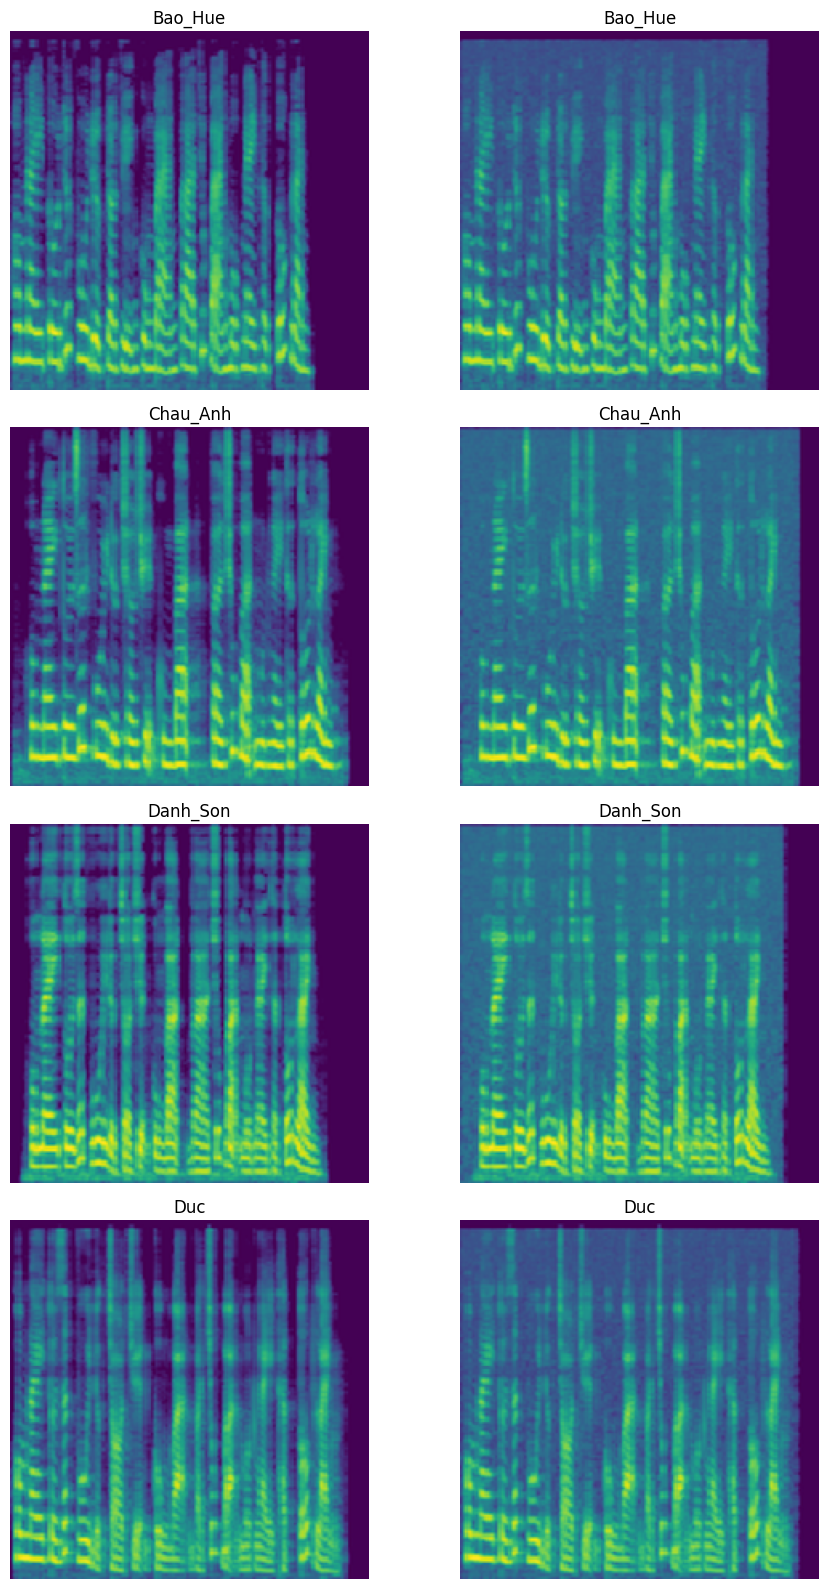

In [5]:
# =============================================
# Visualize Sample Spectrogram Images
# =============================================
def plot_sample_spectrograms(data_dir, num_speakers=4):
    """Display sample spectrogram images from training set"""
    train_path = os.path.join(data_dir, 'train')
    speakers = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])[:num_speakers]
    
    fig, axes = plt.subplots(num_speakers, 2, figsize=(10, 4*num_speakers))
    if num_speakers == 1:
        axes = axes.reshape(1, -1)
    
    for idx, speaker in enumerate(speakers):
        speaker_path = os.path.join(train_path, speaker)
        images = [f for f in os.listdir(speaker_path) if f.endswith('.png')][:2]
        
        for col, img_file in enumerate(images):
            img_path = os.path.join(speaker_path, img_file)
            img = Image.open(img_path)
            
            axes[idx, col].imshow(img)
            axes[idx, col].set_title(f'{speaker}')
            axes[idx, col].axis('off')
    
    plt.tight_layout()
    plt.show()

plot_sample_spectrograms(DATA_DIR, num_speakers=4)

In [6]:
# =============================================
# Section 3: Prepare Dataset for CNN (Data Augmentation & Loading)
# =============================================
# Data augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescale for validation and test sets
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_path = os.path.join(DATA_DIR, 'train')
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Load validation data
val_path = os.path.join(DATA_DIR, 'val')
val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Load test data
test_path = os.path.join(DATA_DIR, 'test')
test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get class labels
class_labels = train_generator.class_indices
num_classes = len(class_labels)
class_names = {v: k for k, v in class_labels.items()}

print(f"Number of speakers: {num_classes}")
print(f"Speaker classes: {class_names}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 532 images belonging to 19 classes.
Found 114 images belonging to 19 classes.
Found 133 images belonging to 19 classes.
Number of speakers: 19
Speaker classes: {0: 'Bao_Hue', 1: 'Chau_Anh', 2: 'Danh_Son', 3: 'Duc', 4: 'Hai_Yen', 5: 'Hung', 6: 'Huong_Ly', 7: 'Jenifer_Smith', 8: 'Lien', 9: 'Linh_Dao', 10: 'Long_Hai', 11: 'Minh_Tam', 12: 'Nam_Minh', 13: 'Nguyen_Lan', 14: 'Phuong_Anh', 15: 'Thomas_Williams', 16: 'Tran_Quyen', 17: 'Trung', 18: 'Van_Son'}
Training samples: 532
Validation samples: 114
Test samples: 133


In [7]:
# =============================================
# Section 4: Build Transfer Learning CNN (ResNet50)
# =============================================
def build_transfer_learning_model(num_classes, input_shape=(224, 224, 3)):
    """
    Build a transfer learning model using ResNet50
    """
    # Load pre-trained ResNet50
    base_model = ResNet50(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Build model
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

# Build model
model, base_model = build_transfer_learning_model(num_classes, input_shape=(224, 224, 3))

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print(model.summary())

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,773,011 (94.50 MB)

 Trainable params: 1,185,299 (4.52 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [8]:
# =============================================
# Section 5: Train the Model
# =============================================
# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    r'D:\Master DS\Intro_to_DS\models\best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Create models directory if it doesn't exist
os.makedirs(r'D:\Master DS\Intro_to_DS\models', exist_ok=True)

# Train the model
print("Training Transfer Learning Model (ResNet50 + Custom Head)...")
print("="*60)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, model_checkpoint],
    verbose=1
)

print("\nTraining completed!")

Training Transfer Learning Model (ResNet50 + Custom Head)...


d:\Master DS\Intro_to_DS\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.0853 - loss: 3.3368
Epoch 1: val_accuracy improved from -inf to 0.05263, saving model to D:\Master DS\Intro_to_DS\models\best_model.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 810ms/step - accuracy: 0.0841 - loss: 3.3354 - val_accuracy: 0.0526 - val_loss: 2.9614 - learning_rate: 1.0000e-04
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.0360 - loss: 3.1792
Epoch 2: val_accuracy improved from 0.05263 to 0.06140, saving model to D:\Master DS\Intro_to_DS\models\best_model.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 637ms/step - accuracy: 0.0361 - loss: 3.1790 - val_accuracy: 0.0614 - val_loss: 2.9541 - learning_rate: 1.0000e-04
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.0460 - loss: 3.1502
Epoch 3: val_accuracy did not improve from 0.06140
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 585ms/step - accuracy: 0.0463 - loss: 3.1501 - val_accuracy: 0.0526 - val_loss: 2.9533 - learning_rate: 1.0000e-04
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.0506 - loss: 3.0908
Epoch 4: val_accuracy did not improve from 0.06140
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 593ms/step - accuracy: 0.0504 - loss: 3.0907 - val_accuracy: 0.0526 - val_loss: 2.9528 - learning_rate: 1.0000e-04
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.0606 - loss: 3.0792
Epoch 5: val_accuracy did not improve from 0.06140
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 608ms/step - accuracy: 0.0604 - loss: 3.0778 - val_accuracy: 0.0526 - val_loss: 2.9494 - learning_rate: 1.0000e-04
Epoch

17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 709ms/step - accuracy: 0.0459 - loss: 2.9854 - val_accuracy: 0.0877 - val_loss: 2.9442 - learning_rate: 5.0000e-05
Epoch 19/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.0559 - loss: 2.9666
Epoch 19: val_accuracy did not improve from 0.08772
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 630ms/step - accuracy: 0.0560 - loss: 2.9666 - val_accuracy: 0.0614 - val_loss: 2.9434 - learning_rate: 5.0000e-05
Epoch 20/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.0452 - loss: 2.9632
Epoch 20: val_accuracy did not improve from 0.08772
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 648ms/step - accuracy: 0.0458 - loss: 2.9632 - val_accuracy: 0.0789 - val_loss: 2.9429 - learning_rate: 5.0000e-05
Epoch 21/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.0574 - loss: 2.9518
Epoch 21: val_accuracy did not improve from 0.08772
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 652ms/step - accuracy: 0.0571 - loss: 2.9519 - val_accuracy: 0.0526 - val_loss: 2.9428 - learning_rate: 5.0000e-05

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 657ms/step - accuracy: 0.0334 - loss: 2.9764 - val_accuracy: 0.0965 - val_loss: 2.9424 - learning_rate: 5.0000e-05
Epoch 26/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.0474 - loss: 2.9565
Epoch 26: val_accuracy did not improve from 0.09649
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 599ms/step - accuracy: 0.0472 - loss: 2.9567 - val_accuracy: 0.0789 - val_loss: 2.9424 - learning_rate: 5.0000e-05
Epoch 27/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.0650 - loss: 2.9678
Epoch 27: val_accuracy did not improve from 0.09649
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 624ms/step - accuracy: 0.0646 - loss: 2.9672 - val_accuracy: 0.0965 - val_loss: 2.9428 - learning_rate: 5.0000e-05
Epoch 28/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.0512 - loss: 2.9660
Epoch 28: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 28: val_accuracy did not improve from 0.09649
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 612ms/step - accuracy: 0.0516 - loss

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 665ms/step - accuracy: 0.0714 - loss: 2.9389 - val_accuracy: 0.1053 - val_loss: 2.9415 - learning_rate: 1.2500e-05
Epoch 42/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.0519 - loss: 2.9490
Epoch 42: val_accuracy did not improve from 0.10526
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 597ms/step - accuracy: 0.0518 - loss: 2.9491 - val_accuracy: 0.0614 - val_loss: 2.9414 - learning_rate: 1.2500e-05
Epoch 43/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.0564 - loss: 2.9466
Epoch 43: val_accuracy did not improve from 0.10526
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 606ms/step - accuracy: 0.0576 - loss: 2.9464 - val_accuracy: 0.0877 - val_loss: 2.9412 - learning_rate: 1.2500e-05
Epoch 44/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.0445 - loss: 2.9502
Epoch 44: val_accuracy did not improve from 0.10526
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 606ms/step - accuracy: 0.0445 - loss: 2.9504 - val_accuracy: 0.0877 - val_loss: 2.9411 - learning_rate: 1.2500e-05

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 653ms/step - accuracy: 0.0620 - loss: 2.9504 - val_accuracy: 0.1140 - val_loss: 2.9413 - learning_rate: 1.2500e-05
Epoch 46/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.0324 - loss: 2.9656
Epoch 46: val_accuracy did not improve from 0.11404
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 596ms/step - accuracy: 0.0327 - loss: 2.9651 - val_accuracy: 0.1140 - val_loss: 2.9413 - learning_rate: 1.2500e-05
Epoch 47/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.0521 - loss: 2.9601
Epoch 47: val_accuracy did not improve from 0.11404
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 608ms/step - accuracy: 0.0526 - loss: 2.9597 - val_accuracy: 0.0965 - val_loss: 2.9413 - learning_rate: 1.2500e-05
Epoch 48/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.0785 - loss: 2.9554
Epoch 48: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.

Epoch 48: val_accuracy did not improve from 0.11404
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 619ms/step - accuracy: 0.0780 - loss:

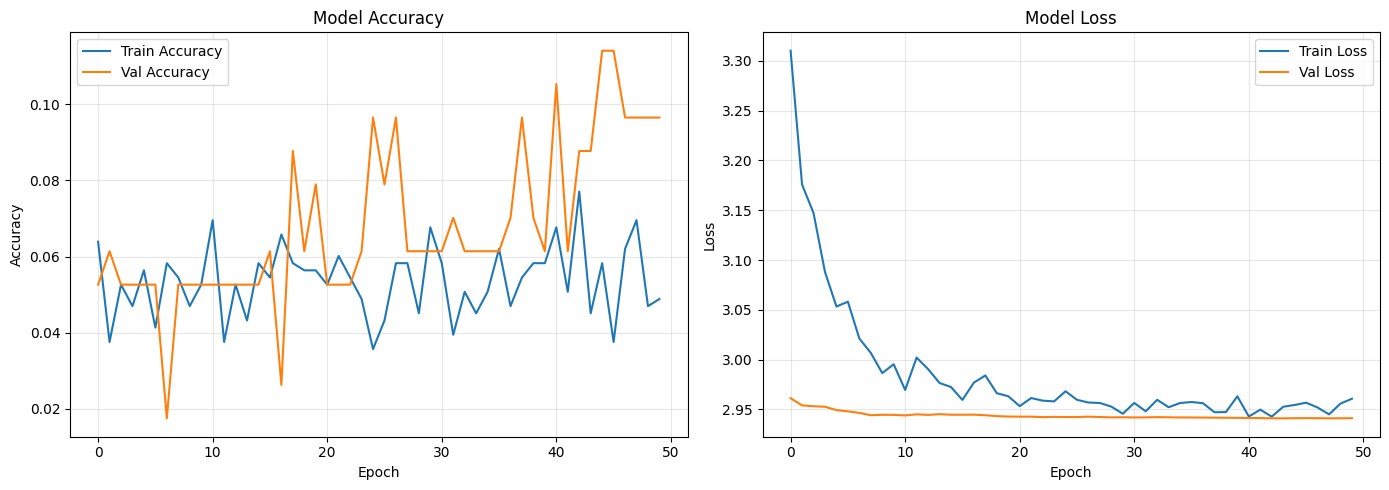

In [9]:
# =============================================
# Section 6: Plot Training History
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# =============================================
# Section 7: Evaluate Model Performance on Test Set
# =============================================
# Reset test generator to start from beginning
test_generator.reset()

# Get predictions on test set
print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions and true labels
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_labels = test_generator.classes

# Classification report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
class_labels_list = [class_names[i] for i in range(num_classes)]
print(classification_report(true_labels, predicted_classes, target_names=class_labels_list))

Evaluating model on test set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - accuracy: 0.0468 - loss: 2.9436

Test Loss: 2.9411
Test Accuracy: 0.0752
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 565ms/step

Classification Report:
                 precision    recall  f1-score   support

        Bao_Hue       0.00      0.00      0.00         7
       Chau_Anh       0.00      0.00      0.00         7
       Danh_Son       0.00      0.00      0.00         7
            Duc       0.00      0.00      0.00         7
        Hai_Yen       0.00      0.00      0.00         7
           Hung       0.00      0.00      0.00         7
       Huong_Ly       0.00      0.00      0.00         7
  Jenifer_Smith       0.00      0.00      0.00         7
           Lien       0.00      0.00      0.00         7
       Linh_Dao       0.00      0.00      0.00         7
       Long_Hai       0.00      0.00      0.00         7
       Minh_Tam       0.00      0.00      0.00         7
       Nam_Minh       0.00      0.00      0.00   

d:\Master DS\Intro_to_DS\.venv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Master DS\Intro_to_DS\.venv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Master DS\Intro_to_DS\.venv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


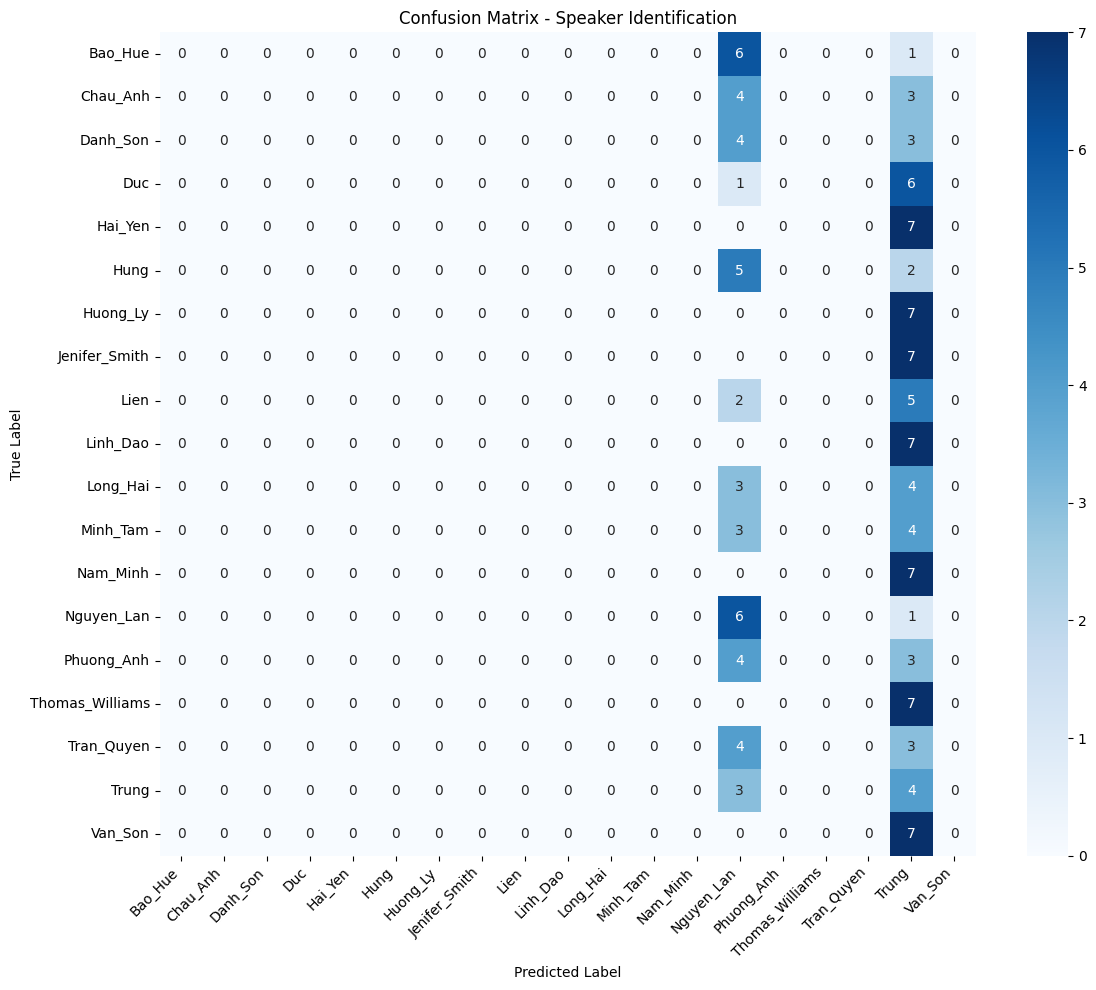

In [11]:
# =============================================
# Confusion Matrix
# =============================================
cm = confusion_matrix(true_labels, predicted_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels_list, 
            yticklabels=class_labels_list)
plt.title('Confusion Matrix - Speaker Identification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

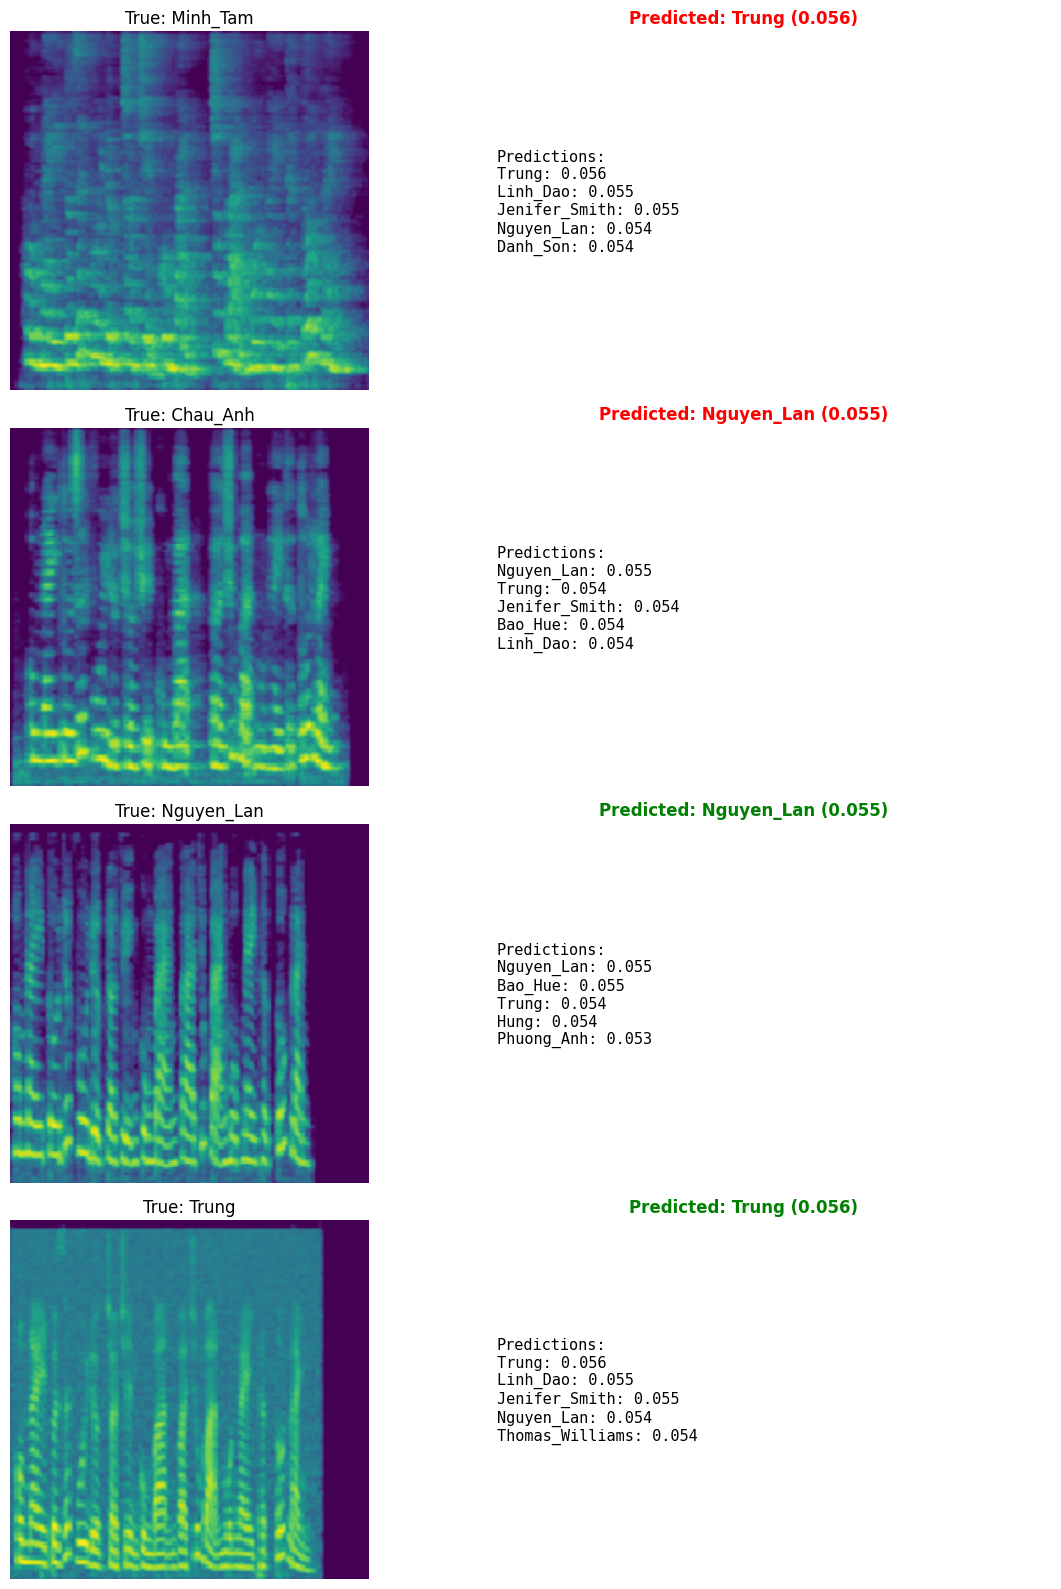

In [12]:
# =============================================
# Section 8: Predict on New Samples
# =============================================
def predict_speaker_from_spectrogram(image_path, model, class_names):
    """Predict speaker from a spectrogram image"""
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    
    # Make prediction
    prediction = model.predict(img, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]
    
    speaker = class_names[predicted_class]
    
    return speaker, confidence, prediction[0]

# Test on some random test images
def predict_on_random_samples(test_path, model, class_names, num_samples=4):
    """Predict on random samples from test set"""
    speakers = sorted(os.listdir(test_path))
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx in range(num_samples):
        speaker = np.random.choice(speakers)
        speaker_path = os.path.join(test_path, speaker)
        images = [f for f in os.listdir(speaker_path) if f.endswith('.png')]
        
        if images:
            img_file = np.random.choice(images)
            img_path = os.path.join(speaker_path, img_file)
            
            # Make prediction
            predicted_speaker, confidence, all_probs = predict_speaker_from_spectrogram(img_path, model, class_names)
            
            # Display image
            img = Image.open(img_path)
            axes[idx, 0].imshow(img)
            axes[idx, 0].set_title(f'True: {speaker}')
            axes[idx, 0].axis('off')
            
            # Display predictions
            sorted_idx = np.argsort(all_probs)[::-1]
            pred_text = "Predictions:\n"
            for i in range(min(5, len(sorted_idx))):
                class_idx = sorted_idx[i]
                pred_text += f"{class_names[class_idx]}: {all_probs[class_idx]:.3f}\n"
            
            axes[idx, 1].text(0.1, 0.5, pred_text, fontsize=11, verticalalignment='center', family='monospace')
            axes[idx, 1].set_title(f'Predicted: {predicted_speaker} ({confidence:.3f})', 
                                   color='green' if predicted_speaker == speaker else 'red',
                                   fontweight='bold')
            axes[idx, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Make predictions on random test samples
test_path = os.path.join(DATA_DIR, 'test')
predict_on_random_samples(test_path, model, class_names, num_samples=4)

In [13]:
# =============================================
# Save Final Results & Model
# =============================================
# Save model
model_path = r'D:\Master DS\Intro_to_DS\models\speaker_identification_cnn.h5'
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save class labels
import json
class_labels_json_path = r'D:\Master DS\Intro_to_DS\models\class_labels.json'
with open(class_labels_json_path, 'w') as f:
    json.dump(class_names, f)
print(f"Class labels saved to: {class_labels_json_path}")

# Save summary to file
summary_path = r'D:\Master DS\Intro_to_DS\models\training_summary.txt'
with open(summary_path, 'w') as f:
    f.write("Speaker Identification CNN - Training Summary\n")
    f.write("="*60 + "\n\n")
    f.write(f"Model: Transfer Learning (ResNet50)\n")
    f.write(f"Image Size: 224x224\n")
    f.write(f"Number of Speakers: {num_classes}\n\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Test Loss: {test_loss:.4f}\n\n")
    f.write("Class Labels:\n")
    for idx, speaker in sorted(class_names.items()):
        f.write(f"  {speaker}: {idx}\n")

print(f"Summary saved to: {summary_path}")
print("\nTraining Complete!")

Model saved to: D:\Master DS\Intro_to_DS\models\speaker_identification_cnn.h5
Class labels saved to: D:\Master DS\Intro_to_DS\models\class_labels.json
Summary saved to: D:\Master DS\Intro_to_DS\models\training_summary.txt

Training Complete!
